In [1]:
import pandas as pd
import numpy as np
import torch
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from tableone import TableOne

In [2]:
# read the dataset.
file_path = r"D:\Singapore\Alzheimer\R files\final data_new\final_data_imputed_k1.csv"
df = pd.read_csv(file_path, index_col=0)
print(df)
print(df.shape)

      AGE  PTGENDER  PTEDUCAT  PTRACCAT  PTMARRY  APOE4       FDG    AV45  \
RID                                                                         
4      68         0        10         0        0      0  1.281469  0.9643   
5      74         0        16         0        0      0  1.259559  1.4170   
6      80         1        13         0        0      0  1.123660  1.6112   
8      84         1        18         0        0      0  1.209653  1.0237   
16     65         0         9         1        0      1  1.437162  1.1284   
...   ...       ...       ...       ...      ...    ...       ...     ...   
7000   90         1        16         0        0      0  1.315612  1.0361   
7010   59         0        18         0        0      1  1.309278  1.0981   
7012   57         1        16         1        1      1  1.484340  0.9960   
7060   76         0        15         0        0      0  1.315612  1.0361   
7105   78         0        18         2        0      0  1.315612  1.0361   

In [3]:
df.columns

Index(['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'APOE4', 'FDG',
       'AV45', 'ABETA', 'TAU', 'PTAU', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4',
       'MMSE_bl', 'RAVLT.immediate', 'LDELTOTAL', 'TRABSCOR', 'FAQ',
       'EcogPtTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles',
       'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV',
       'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting',
       'MOCA_bl', 'vascular', 'convert_Within_3Years'],
      dtype='object')

In [4]:
x = df.values[:, 1:36]
y = df.values[:, 36]

In [5]:
# Step 1: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=100
)

In [6]:
type(X_train)

numpy.ndarray

In [7]:
param_dist = {
    'n_estimators': [50, 100],                # fewer trees may help regularize
    'max_depth': [4, 6],                     # shallower trees
    'min_samples_split': [10, 15, 20],        # need more samples to split
    'min_samples_leaf': [6, 8, 10],          # enforce minimum leaf size
    'max_features': ['sqrt'],                 # good for generalization
    'bootstrap': [True]                       # keep bootstrapping for robustness
}

In [8]:
# Step 3: Define CV strategy and Random Forest
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)
forest = RandomForestClassifier(random_state=100, class_weight='balanced')

In [9]:
# Step 4: Tune hyperparameters with RandomizedSearchCV
random_search = RandomizedSearchCV(
    forest, param_distributions=param_dist,
    n_iter=20, cv=cv, scoring='roc_auc', random_state=100)
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=100)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'max_depth': [4, 6], 'max_features': ['sqrt'], 'min_samples_leaf': [6, 8, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.2

In [10]:
# Step 5: Get the best model
best_model = random_search.best_estimator_

In [11]:
# Step 6: Evaluate AUCs
# 6.1 - Train AUC
y_train_proba = best_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_proba)

In [12]:
# 6.2 - Test AUC
y_test_proba = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

In [13]:
# 6.3 - Validation AUC from cross-validation
cv_auc = random_search.best_score_

In [14]:
# Step 7: Print results
print("Best hyperparameters:", random_search.best_params_)
print(f"Train ROC AUC:{train_auc:.3}")
print(f"Validation (CV) ROC AUC:{cv_auc:.3}")
print(f"Test ROC AUC:{test_auc:.3}")

Best hyperparameters: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': 6, 'bootstrap': True}
Train ROC AUC:0.989
Validation (CV) ROC AUC:0.955
Test ROC AUC:0.959


In [15]:
feature_names = df.columns[1:36].tolist()
feature_names = np.array(feature_names)
feature_names

array(['PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'APOE4', 'FDG',
       'AV45', 'ABETA', 'TAU', 'PTAU', 'CDRSB', 'ADAS11', 'ADAS13',
       'ADASQ4', 'MMSE_bl', 'RAVLT.immediate', 'LDELTOTAL', 'TRABSCOR',
       'FAQ', 'EcogPtTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID',
       'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal',
       'Fusiform', 'MidTemp', 'ICV', 'RAVLT.learning', 'RAVLT.forgetting',
       'RAVLT.perc.forgetting', 'MOCA_bl', 'vascular'], dtype='<U21')

In [16]:
print(feature_names)
print(type(feature_names))
print("*")
feature_names_1 = feature_names.tolist()
print(feature_names_1)
print(type(feature_names_1))

['PTGENDER' 'PTEDUCAT' 'PTRACCAT' 'PTMARRY' 'APOE4' 'FDG' 'AV45' 'ABETA'
 'TAU' 'PTAU' 'CDRSB' 'ADAS11' 'ADAS13' 'ADASQ4' 'MMSE_bl'
 'RAVLT.immediate' 'LDELTOTAL' 'TRABSCOR' 'FAQ' 'EcogPtTotal' 'FLDSTRENG'
 'FSVERSION' 'IMAGEUID' 'Ventricles' 'Hippocampus' 'WholeBrain'
 'Entorhinal' 'Fusiform' 'MidTemp' 'ICV' 'RAVLT.learning'
 'RAVLT.forgetting' 'RAVLT.perc.forgetting' 'MOCA_bl' 'vascular']
<class 'numpy.ndarray'>
*
['PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'APOE4', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE_bl', 'RAVLT.immediate', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'MOCA_bl', 'vascular']
<class 'list'>


In [17]:
table = TableOne(
    data=df,
    columns=feature_names_1,
    groupby='convert_Within_3Years',
    pval=True
)
print(table.tabulate(tablefmt="fancy_grid"))

╒══════════════════════════════════╤════╤═══════════╤══════════════════════╤══════════════════════╤══════════════════════╤═══════════╕
│                                  │    │ Missing   │ Overall              │ 0                    │ 1                    │ P-Value   │
╞══════════════════════════════════╪════╪═══════════╪══════════════════════╪══════════════════════╪══════════════════════╪═══════════╡
│ n                                │    │           │ 677                  │ 570                  │ 107                  │           │
├──────────────────────────────────┼────┼───────────┼──────────────────────┼──────────────────────┼──────────────────────┼───────────┤
│ PTGENDER, n (%)                  │ 0  │           │ 371 (54.8)           │ 304 (53.3)           │ 67 (62.6)            │ 0.096     │
├──────────────────────────────────┼────┼───────────┼──────────────────────┼──────────────────────┼──────────────────────┼───────────┤
│                                  │ 1  │           │ 3

In [18]:
importances = random_search.best_estimator_.feature_importances_


In [19]:
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [20]:
# Sorts the rows of importance_df from most important feature to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
21,FSVERSION,1.202154e-01
12,ADAS13,1.119518e-01
15,RAVLT.immediate,9.961272e-02
16,LDELTOTAL,8.774022e-02
22,IMAGEUID,8.360663e-02
13,ADASQ4,5.725684e-02
11,ADAS11,5.698431e-02
5,FDG,3.389136e-02
10,CDRSB,3.269326e-02
18,FAQ,3.090006e-02


In [21]:
# Sort importances
indices = np.argsort(importances)[::-1]  # descending order


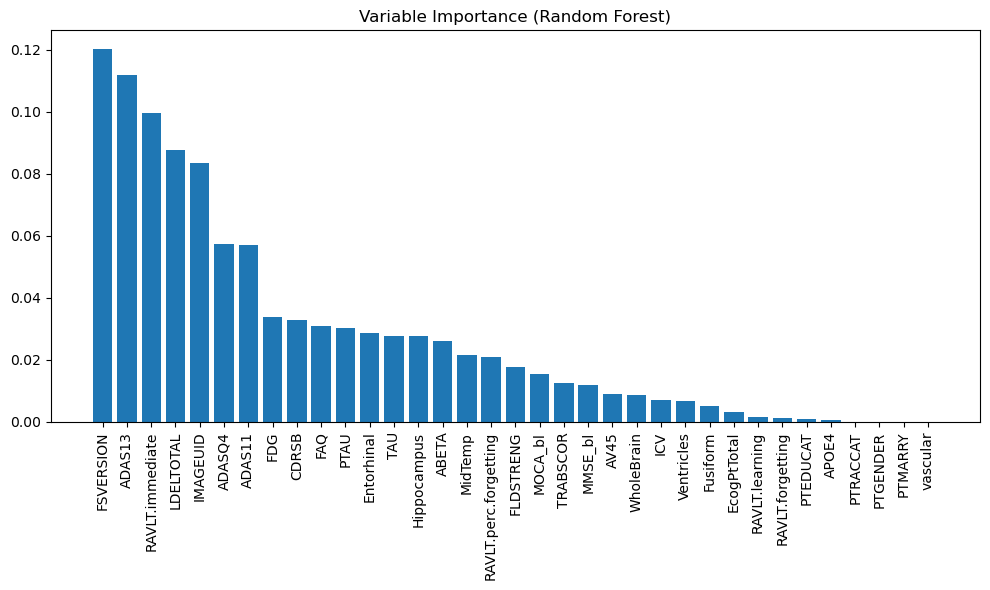

In [22]:
plt.figure(figsize=(10, 6))
plt.title("Variable Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [23]:
# Permutation Feature Importance
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=50,
    random_state=42,
    scoring='roc_auc'
)


perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Permutation Importance (Mean)': perm_importance.importances_mean,
    'Permutation Importance (Std)': perm_importance.importances_std
})

perm_df = perm_df.sort_values(by='Permutation Importance (Mean)', ascending=False)

perm_df

,Feature,Permutation Importance (Mean),Permutation Importance (Std)
21,FSVERSION,0.021802,0.008679
18,FAQ,0.010916,0.003432
15,RAVLT.immediate,0.010789,0.005049
8,TAU,0.008797,0.004947
22,IMAGEUID,0.008790,0.005395
9,PTAU,0.007424,0.003301
5,FDG,0.006686,0.003493
12,ADAS13,0.006195,0.006136
16,LDELTOTAL,0.005520,0.005114
10,CDRSB,0.004971,0.004314
